In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv('P53.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7467 entries, 0 to 7466
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mutant            7467 non-null   object 
 1   mutated_sequence  7467 non-null   object 
 2   DMS_score         7467 non-null   float64
 3   DMS_score_bin     7467 non-null   int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 233.5+ KB


In [ ]:
data.head()
# The column "mutant" is an ID, "mutated_sequence" is the amino acid sequence of the mutant
# DMS_score is the log-normalized functional score of the mutant, and "DMS_score_bin"
# is the binarized version of DMS_score, where 1 indicates a functional mutant and 0 
# indicates a non-functional mutant.

,mutant,mutated_sequence,DMS_score,DMS_score_bin
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0


In [7]:
data["DMS_score"].describe()

count    7467.000000
mean        0.046731
std         0.978440
min        -3.943922
25%        -0.499698
50%         0.350252
75%         0.738673
max         2.533067
Name: DMS_score, dtype: float64

Data Exploration; informative plots to learn more about the distributions of the data

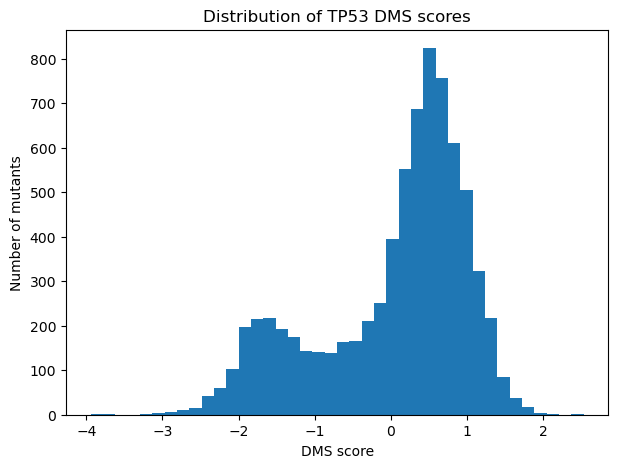

In [11]:
plt.figure(figsize=(7, 5))
plt.hist(data["DMS_score"], bins=40)
plt.xlabel("DMS score")
plt.ylabel("Number of mutants")
plt.title("Distribution of TP53 DMS scores")
plt.show()

The above plot shows us the distribution of DMS scores of the mutants in our data. They are not evenly distributed. Many mutants have scores near 0 and 1, which suggests that many of the mutations have neutral to mildly functional effects. There is also a significant group centered between -1 and -2, which tells us that a subset of the mutations was detrimental or loss-of-function. This spread supports predicting on the DMS_score_bin, because the continuous group separates into lower and higher groups and there is a meaningful boundary betwen the categories 

In [14]:
# We can extract information about the position of the mutation. 
# The "mutant" column has format X123Y, where X is the wild-type amino acid, 
# 123 is the position of the mutation, and Y is the mutant amino acid.

data["position"] = data["mutant"].str.extract(r"(\d+)").astype(int)
data["wt_aa"] = data["mutant"].str[0]
data["mut_aa"] = data["mutant"].str[-1]

data.head()

,mutant,mutated_sequence,DMS_score,DMS_score_bin,position,wt_aa,mut_aa
0,M1A,AEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.788753,0,1,M,A
1,M1C,CEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.969077,0,1,M,C
2,M1Y,YEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-1.333315,0,1,M,Y
3,M1W,WEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-2.219256,0,1,M,W
4,M1V,VEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,-0.669727,0,1,M,V


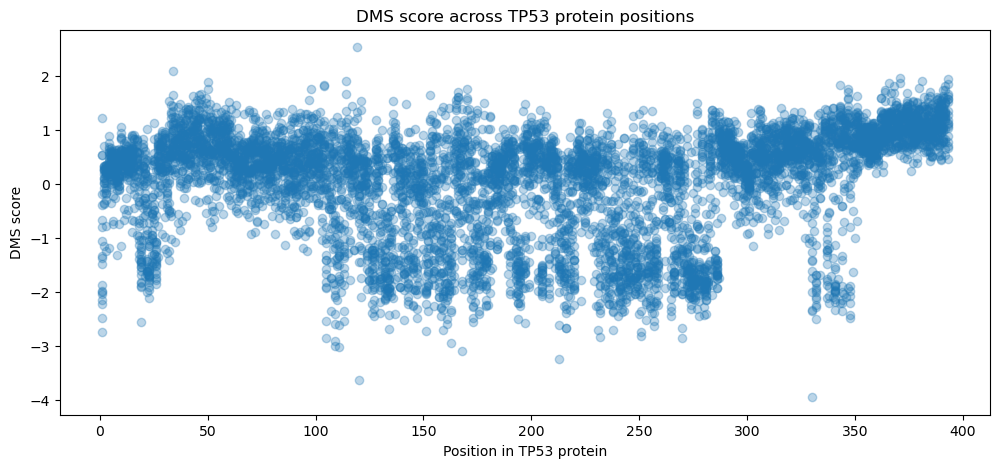

In [15]:
plt.figure(figsize=(12, 5))
plt.scatter(data["position"], data["DMS_score"], alpha=0.3)

plt.xlabel("Position in TP53 protein")
plt.ylabel("DMS score")
plt.title("DMS score across TP53 protein positions")
plt.show()

This scatterplot shows the DMS score for each mutation across positions in the TP53 protein. Each point represents one row/mutant amino acid substitution at a specific position. This plot tells us that the mutation effects are not evenly distributed across TP53's amino acid sequence. Some regions, such as around positions 350-400, are more tolerant of mutations and show a high concentration of neutral/positive effect mutations, and little to no negative scores. Regions such as around positions 100-300 show many low DMS scores, which indicates that mutations in these regions is very detrimental to the function of the protein.